# 02｜训练规则与超参数：模型到底怎样学习？

本页不追求分类准确率，而是用小例子解释训练循环中的常用概念：

`Sample`、`Batch`、`Batch size`、`Iteration/Step`、`Epoch`、`Loss`、`Gradient` 和 `Learning rate`。

先记住一条主线：

```text
取一个 Batch → 前向计算 → 计算 Loss → 反向传播 → 更新参数 → 取下一个 Batch
```

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import math

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (LAB_DIR / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from mlp_lab import make_dataset
from mlp_lab.plots import configure_chinese_font

configure_chinese_font()

## 1｜Batch、Iteration 和 Epoch

| 概念 | 含义 |
|---|---|
| Sample | 一个样本 $(\mathbf{x}_i,y_i)$ |
| Batch | 一次送入模型的一小组样本 |
| Batch size | 一个 Batch 中的样本数，记为 $B$ |
| Iteration / Step | 使用一个 Batch 完成一次参数更新 |
| Epoch | 全部训练样本都被使用一遍 |

若训练集有 $N$ 个样本，则每个 Epoch 的更新次数为：

$$
\text{steps per epoch}=\left\lceil\frac{N}{B}\right\rceil
$$

例如 $N=12$、$B=4$ 时，每个 Epoch 有 3 个 Step；训练 2 个 Epoch，一共更新 6 次。

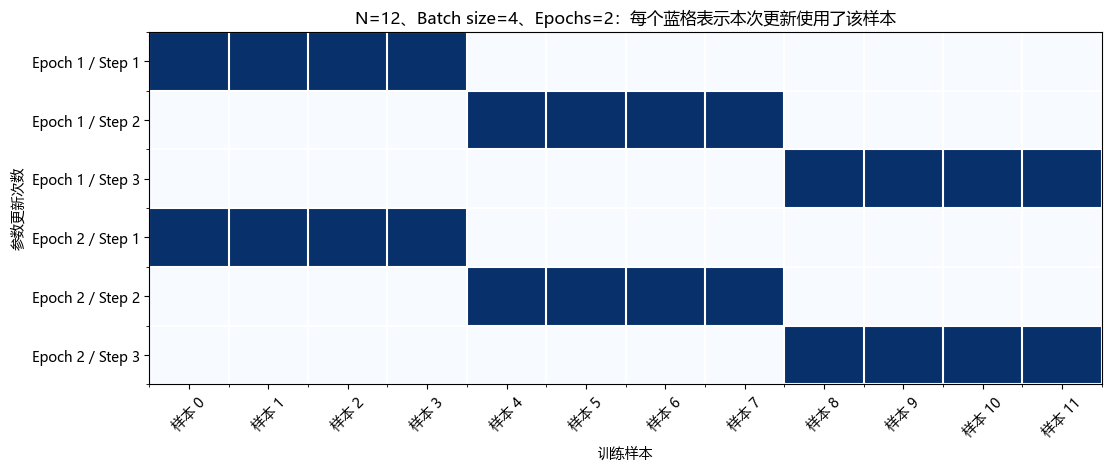

每个 Epoch 的 Step 数： 3
总参数更新次数： 6


In [2]:
n_samples = 12
batch_size = 4
epochs = 2
steps_per_epoch = math.ceil(n_samples / batch_size)
total_steps = epochs * steps_per_epoch

seen = np.zeros((total_steps, n_samples))
row_labels = []
row = 0
for epoch in range(epochs):
    for step, start in enumerate(range(0, n_samples, batch_size), start=1):
        indices = np.arange(start, min(start + batch_size, n_samples))
        seen[row, indices] = 1
        row_labels.append(f"Epoch {epoch + 1} / Step {step}")
        row += 1

fig, ax = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
ax.imshow(seen, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n_samples), [f"样本 {i}" for i in range(n_samples)], rotation=45)
ax.set_yticks(range(total_steps), row_labels)
ax.set_title("N=12、Batch size=4、Epochs=2：每个蓝格表示本次更新使用了该样本")
ax.set_xlabel("训练样本")
ax.set_ylabel("参数更新次数")
ax.set_xticks(np.arange(-0.5, n_samples, 1), minor=True)
ax.set_yticks(np.arange(-0.5, total_steps, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
plt.show()

print("每个 Epoch 的 Step 数：", steps_per_epoch)
print("总参数更新次数：", total_steps)

**容易混淆的地方：**

- `Batch size=4` 表示一次使用 4 个样本，不是“一共有 4 个 Batch”；
- 一个 Epoch 通常包含多个 Step；
- Epoch 增加意味着重复观察训练集，但数据顺序通常会重新打乱；
- Batch 太小，梯度波动可能更大；Batch 太大，则一次更新的计算和显存需求更高。

## 2｜Loss、Gradient 和 Learning rate

对一个 Batch，模型先得到预测：

$$
\widehat{Y}_B=f_{\theta}(X_B)
$$

再计算平均损失：

$$
\mathcal{L}_B(\theta)=\frac{1}{B}\sum_{i\in B}\ell(f_{\theta}(\mathbf{x}_i),y_i)
$$

反向传播得到梯度 $\nabla_{\theta}\mathcal{L}_B$。最简单的梯度下降更新为：

$$
\theta_{t+1}=\theta_t-\eta\nabla_{\theta}\mathcal{L}_B
$$

$\eta$ 就是 Learning rate（学习率）：它控制每次沿梯度方向走多大一步。

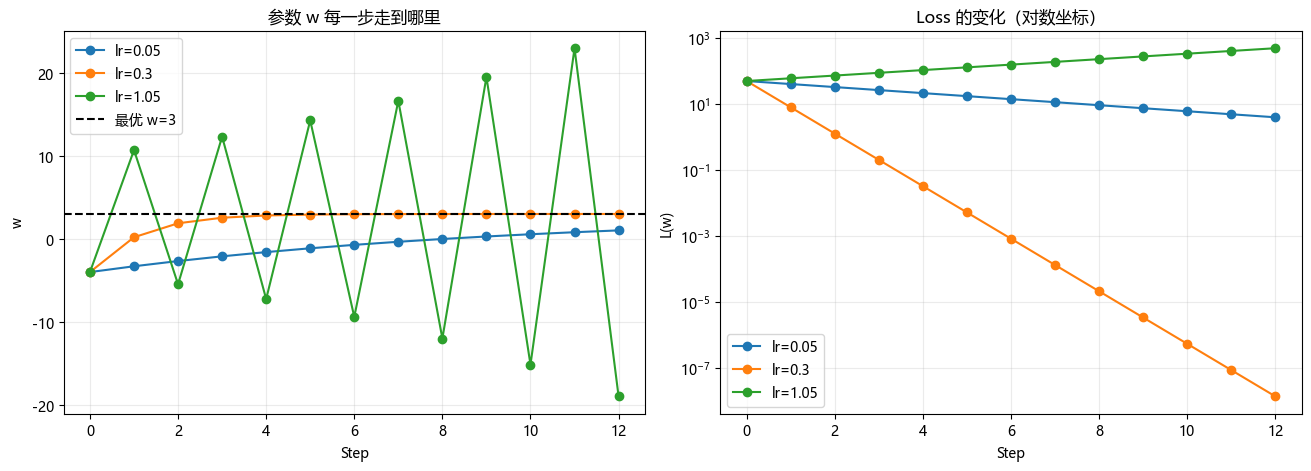

In [3]:
def optimize_quadratic(learning_rate, steps=12):
    """在 L(w)=(w-3)^2 上做最简单的梯度下降。"""
    w = -4.0
    weights = [w]
    losses = [(w - 3.0) ** 2]
    for _ in range(steps):
        gradient = 2.0 * (w - 3.0)
        w = w - learning_rate * gradient
        weights.append(w)
        losses.append((w - 3.0) ** 2)
    return np.array(weights), np.array(losses)

learning_rates = [0.05, 0.30, 1.05]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for lr in learning_rates:
    weights, losses = optimize_quadratic(lr)
    axes[0].plot(weights, marker="o", label=f"lr={lr}")
    axes[1].plot(losses, marker="o", label=f"lr={lr}")

axes[0].axhline(3.0, color="black", linestyle="--", label="最优 w=3")
axes[0].set_title("参数 w 每一步走到哪里")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("w")
axes[1].set_yscale("log")
axes[1].set_title("Loss 的变化（对数坐标）")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("L(w)")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

从图中可以形成直觉：

- 学习率太小：方向可能正确，但前进很慢；
- 学习率合适：能够较快接近低 Loss 区域；
- 学习率太大：可能越过最低点、来回震荡，甚至发散。

这里的 $0.30$ 只适用于这个二次函数示例，并不是所有模型的“最佳学习率”。

## 3｜一次真实的 PyTorch 参数更新

一次训练 Step 通常只有五个动作：

```python
optimizer.zero_grad()  # 清空旧梯度
logits = model(X_batch) # 前向计算
loss = loss_fn(logits, y_batch)
loss.backward()         # 反向传播
optimizer.step()        # 更新参数
```

下面使用 4 个二维样本和一个最简单的线性分类层，观察 Loss、梯度和权重是否真的发生变化。

In [4]:
torch.manual_seed(42)
X_batch = torch.tensor([[1.0, 0.0], [0.8, 0.2], [-1.0, 0.0], [-0.8, -0.2]])
y_batch = torch.tensor([1, 1, 0, 0])

model = nn.Linear(2, 2)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

weight_before = model.weight.detach().clone()
optimizer.zero_grad()
logits = model(X_batch)
loss_before = loss_fn(logits, y_batch)
loss_before.backward()
gradient_norm = model.weight.grad.norm().item()
optimizer.step()

with torch.no_grad():
    loss_after = loss_fn(model(X_batch), y_batch)
weight_change = (model.weight.detach() - weight_before).norm().item()

print("X_batch shape：", tuple(X_batch.shape))
print("logits shape：", tuple(logits.shape))
print(f"更新前 Loss：{loss_before.item():.4f}")
print(f"权重梯度范数：{gradient_norm:.4f}")
print(f"权重改变量：{weight_change:.4f}")
print(f"更新后 Loss：{loss_after.item():.4f}")

assert gradient_norm > 0 and weight_change > 0

X_batch shape： (4, 2)
logits shape： (4, 2)
更新前 Loss：1.0672
权重梯度范数：0.8334
权重改变量：0.0833
更新后 Loss：0.9981


## 4｜把概念对应到后面的 MLP 实验

后面的基线通常使用 `batch_size=64` 和若干个 Epoch。下面直接计算一次实际实验会进行多少次参数更新。

In [5]:
data = make_dataset("spiral", n_samples=450, noise=0.45, seed=42)
batch_size = 64
epochs = 60
steps_per_epoch = math.ceil(len(data.x_train) / batch_size)

print("训练样本数：", len(data.x_train))
print("Batch size：", batch_size)
print("每个 Epoch 的 Step 数：", steps_per_epoch)
print("训练 Epoch 数：", epochs)
print("总参数更新次数：", steps_per_epoch * epochs)

训练样本数： 337
Batch size： 64
每个 Epoch 的 Step 数： 6
训练 Epoch 数： 60
总参数更新次数： 360


## 本页小结

```text
训练集
  ↓ 切成多个 Batch
前向计算预测
  ↓
Loss 衡量预测误差
  ↓
反向传播得到 Gradient
  ↓
优化器按 Learning rate 更新参数
  ↓
全部 Batch 用完一次 = 1 Epoch
```

下一页将真正训练第一个 MLP。读图时请把 Loss 曲线上的每个 Epoch，理解为“模型已经完整看过训练集一次”。